In [1]:
# 1. Univariate Linear Regression

# Part 1: Setup and Import Libraries
# ===============================
# Import Required Libraries
# ===============================
# Numerical computing
import numpy as np
# Data manipulation
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Regression algorithms
from sklearn.linear_model import LinearRegression
# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)
# Statistical analysis
from scipy import stats
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# To improve the apperance of the visualization
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")
# Set default color palette
sns.set_palette("husl")
print ("liberary setup successfully")

liberary setup successfully


In [2]:
# ============================================
# Part 2: Load and Explore the Dataset
# ============================================

try:
    # California Housing Dataset URL
    url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

    # Load dataset from URL
    df = pd.read_csv(url)

    print("Dataset loaded successfully from URL!")

except Exception as e:

    print("URL download failed.")
    print("Error:", e)
    print("Generating synthetic dataset...")

    # Set random seed
    np.random.seed(42)

    # Number of samples
    n_samples = 5000

    # Create synthetic dataset
    df = pd.DataFrame({
        "longitude": np.random.uniform(-124.5, -114.5, n_samples),
        "latitude": np.random.uniform(32.5, 42.0, n_samples),
        "housing_median_age": np.random.randint(1, 52, n_samples),
        "total_rooms": np.random.normal(2000, 1000, n_samples).astype(int),
        "total_bedrooms": np.random.normal(500, 250, n_samples).astype(int),
        "population": np.random.normal(1200, 800, n_samples).astype(int),
        "households": np.random.normal(450, 250, n_samples).astype(int),
        "median_income": np.random.uniform(0.5, 15, n_samples),
        "ocean_proximity": np.random.choice(
            [
                "NEAR BAY",
                "<1H OCEAN",
                "INLAND",
                "NEAR OCEAN",
                "ISLAND"
            ],
            size=n_samples,
            p=[0.30, 0.30, 0.30, 0.09, 0.01]
        )
    })

    # Create median house value
    df["median_house_value"] = (
        df["median_income"] * 40000 +
        df["housing_median_age"] * 1000 +
        df["total_rooms"] * 20 +
        np.random.normal(0, 30000, n_samples)
    ).astype(int)

    # Limit prices
    df["median_house_value"] = df["median_house_value"].clip(
        lower=50000,
        upper=500001
    )

    print("Synthetic dataset created successfully!")


# ============================================
# Display first few rows
# ============================================
print(df.head())

# ============================================
# Check Missing Values
# ============================================

print("\nMissing Values")
print("-" * 50)
print(df.isnull().sum())

print("\nMissing Values")
print("-" * 50)
df.dropna()

Dataset loaded successfully from URL!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Missing Values
---------------------

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
# ============================================
# Step 1: Select Features
# ============================================
# Independent variable (X)
X = df[['median_income']]
# Target variable (y)
y = df['median_house_value']

In [4]:
# ============================================
# Step 2: Split the Dataset
# ============================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)
# print("Splited Sucessfully")

In [5]:
# ============================================
# Step 3: Train the Model
# ============================================
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# ============================================
# Step 4: View the Equation
# ============================================
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")

Intercept : 44459.73
Coefficient : 41933.85


In [7]:
# ============================================
# Step 5: Make Predictions
# ============================================
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
print("Models are Pridicted and Tested  sucessfully ")

Models are Pridicted and Tested  sucessfully 


In [8]:
# ============================================
# Step 6: Evaluate the Model
# ============================================
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)
print("\n Training RMSE:",train_rmse)
print("\n Testing RMSE:",test_rmse)
print("\n Training R2:",train_r2)
print("\n Testing R2:",test_r2)


 Training RMSE: 83614.87409655548

 Testing RMSE: 84209.01241414454

 Training R2: 0.4769927345820525

 Testing R2: 0.45885918903846656


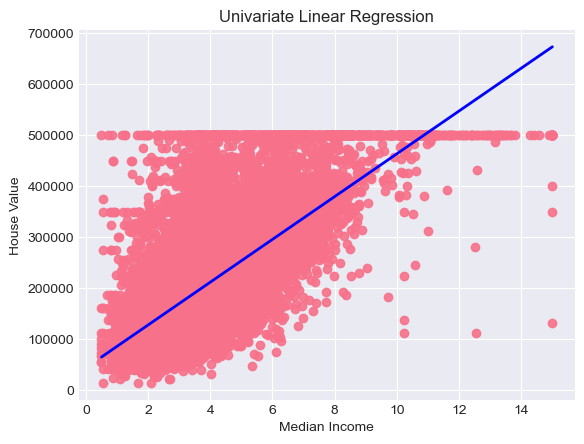

In [9]:
# ============================================
# Step 7: Plot the Regression Line
# ============================================
plt.scatter(X_train, y_train, alpha=0.9)
X_sorted = X_train.sort_values("median_income")
y_sorted = model.predict(X_sorted)
plt.plot(
X_sorted,
y_sorted,
color="blue",
linewidth=2
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Univariate Linear Regression")
plt.show()

In [10]:
# 2. Multivariate Linear Regression
print("======================================================")
print("Multivariate Linear Regression Starts from Hear")
print("======================================================")

Multivariate Linear Regression Starts from Hear


In [11]:
# ============================================
# Step 1: Encode Categorical Data
# ============================================
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["ocean_proximity_encoded"] = encoder.fit_transform(
df["ocean_proximity"]
)
print(df["ocean_proximity_encoded"])

0        3
1        3
2        3
3        3
4        3
        ..
20635    1
20636    1
20637    1
20638    1
20639    1
Name: ocean_proximity_encoded, Length: 20640, dtype: int64


In [12]:
# ============================================
# Step 2: Select Features
# ============================================
features = [
"median_income",
"housing_median_age",
"total_rooms",
"total_bedrooms",
"population",
"households",
"latitude",
"longitude",
"ocean_proximity_encoded"
]
X = df[features]
y = df["median_house_value"]


In [13]:
# ============================================
# Step 3: Split the Dataset
# ============================================

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)
print("Model split sucessfully")

Model split sucessfully


In [14]:
# ============================================
# Step 4: Train the Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_multi, y_train_multi)
# ============================================

LinearRegression()

In [15]:
# ============================================
# Step 5: View the Equation
# ============================================
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")


Intercept : -3594630.76
Coefficient : 40511.83


In [16]:
# ============================================
# Step 6: Make Predictions
# ============================================
X_test_multi["total_bedrooms"] = X_test_multi["total_bedrooms"].fillna(
    X_train_multi["total_bedrooms"].mean()
)

train_predictions = model.predict(X_train_multi)
y_pred_multi_test = model.predict(X_test_multi)
print("Pridicted successfully")

Pridicted successfully


In [17]:
# ============================================
# Step 7:  Evaluate the Model
# ============================================
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
train_rmse_multi = np.sqrt(mean_squared_error(y_train_multi, train_predictions))
test_rmse_multi = np.sqrt(mean_squared_error(y_test_multi, test_predictions))
train_r2_multi = r2_score(y_train, train_predictions)
test_r2_multi = r2_score(y_test, y_pred_multi_test)
print("\n Training RMSE:",train_rmse_multi)
print("\n Testing RMSE:",test_rmse_multi)
print("\n Training R2:",train_r2_multi)
print("\n Testing R2:",test_r2_multi)


 Training RMSE: 69361.0714290645

 Testing RMSE: 84209.01241414454

 Training R2: 0.6401079709888613

 Testing R2: 0.6142405424710499


In [18]:
coefficients = pd.DataFrame({
"Feature": features,
"Coefficient": model.coef_
})
coefficients["Absolute"] = coefficients["Coefficient"].abs()
coefficients.sort_values(
"Absolute",
ascending=False,
inplace=True
)
print(coefficients)

                   Feature   Coefficient      Absolute
7                longitude -42807.765844  42807.765844
6                 latitude -42565.776179  42565.776179
0            median_income  40511.833197  40511.833197
1       housing_median_age   1184.269729   1184.269729
8  ocean_proximity_encoded   -318.827157    318.827157
3           total_bedrooms    116.392023    116.392023
5               households     46.202961     46.202961
4               population    -38.595709     38.595709
2              total_rooms     -8.136388      8.136388


In [19]:
# Create a summary DataFrame
comparison = pd.DataFrame({
"Model": [
"Univariate (Median Income)",
"Multivariate (All Features)"
],
"Train RMSE": [train_rmse, train_rmse_multi],
"Test RMSE": [test_rmse, test_rmse_multi],
"Train R²": [train_r2, train_r2_multi],
"Test R²": [test_r2, test_r2_multi]
})
print("Model Performance Comparison")
print(comparison.round(2))

Model Performance Comparison
                         Model  Train RMSE  Test RMSE  Train R²  Test R²
0   Univariate (Median Income)    83614.87   84209.01      0.48     0.46
1  Multivariate (All Features)    69361.07   84209.01      0.64     0.61


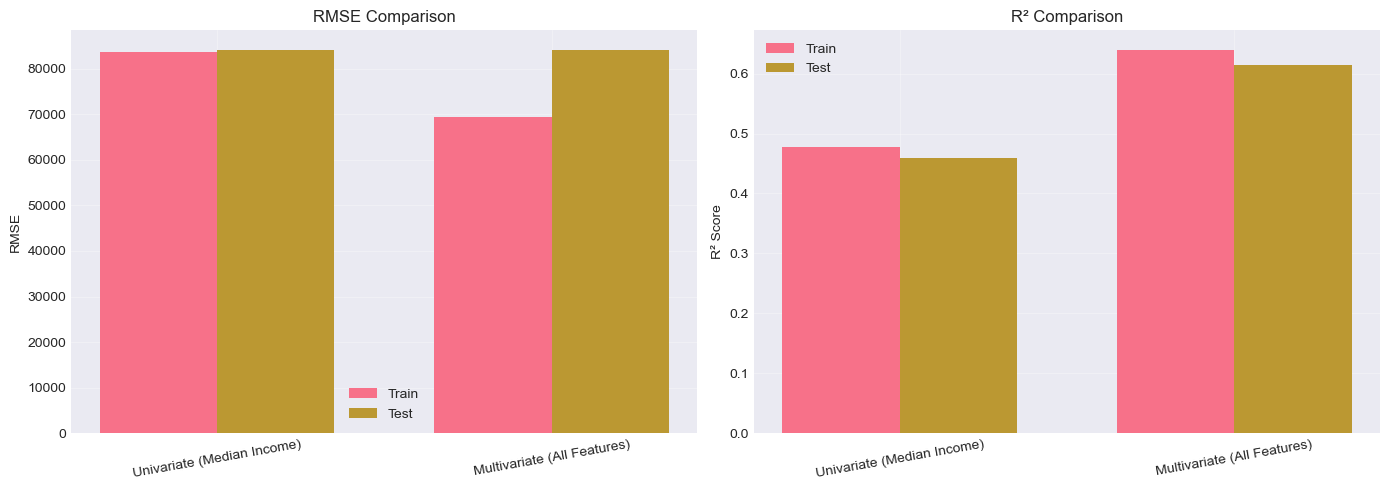

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))
width = 0.35
# -----------------------------
# RMSE Comparison
# -----------------------------
axes[0].bar(
x - width/2,
comparison["Train RMSE"],
width,
label="Train"
)

axes[0].bar(
x + width/2,
comparison["Test RMSE"],
width,
label="Test"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -----------------------------
# R² Comparison
# -----------------------------
axes[1].bar(
x - width/2,
comparison["Train R²"],
width,
label="Train"
)
axes[1].bar(
x + width/2,
comparison["Test R²"],
width,
label="Test"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Resedual   Analysis
residuals = y_test - y_pred_multi_test

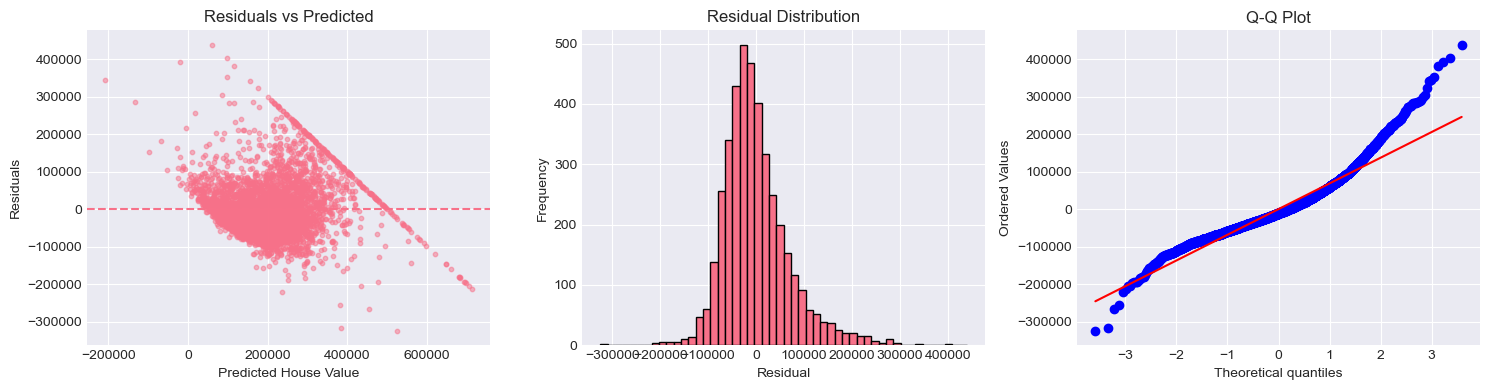

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# -----------------------------------
# Residuals vs Predicted Values
# -----------------------------------
axes[0].scatter(
y_pred_multi_test,
residuals,
alpha=0.5,
s=10
)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted House Value")
axes[0].set_ylabel("Residuals")
# -----------------------------------
# Histogram
# -----------------------------------
axes[1].hist(
residuals,
bins=50,
edgecolor="black"
)

axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
# -----------------------------------
# Q-Q Plot
# -----------------------------------
stats.probplot(
residuals,
dist="norm",
plot=axes[2]
)
axes[2].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

In [24]:
print("Residual Statistics")
print(f"Mean : ${residuals.mean():,.2f}")
print(f"Std Dev : ${residuals.std():,.2f}")
print(f"Skewness : {residuals.skew():.4f}")

Residual Statistics
Mean : $487.22
Std Dev : $71,105.65
Skewness : 1.1209
